In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mervebzn/employee-attrition/Employee-Attrition.csv


# ****Initial Exploration****

In [3]:
df= pd.read_csv("/kaggle/input/datasets/mervebzn/employee-attrition/Employee-Attrition.csv")
print("Shape (rows,columns):", df.shape)

Shape (rows,columns): (1470, 35)


In [4]:
#Missing Values
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [6]:
# Nunique value count per column
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [7]:
# EmployeeCount, Over18 and StandartHours hold the same value in every row(constant - zero variance)
# A constant column can`t explain any difference between employees, so we exclude it from the analysis.
df_clean= df.drop(columns=["StandardHours","Over18", "EmployeeCount"])

In [8]:
df_clean.shape

(1470, 32)

In [9]:
# Convert the Attrition (Yes/No) column into a 0/1 numeric column
df_clean["AttritionFlag"] = df_clean["Attrition"].map({"Yes":1, "No":0})
print(df_clean["AttritionFlag"].mean())

0.16122448979591836


In [10]:
# Convert the continuous Age variable into discrete decade-based age brackets (18-29, 30-39, 40-49, 50-60).
min_val = df_clean["Age"].min()-1
max_val = df_clean["Age"].max()

bins = [min_val, 29, 39, 49, max_val]
labels= ["18-29", "30-39", "40-49", "50-60"]                                                      

df_clean["AgeGroup"] =pd.cut(df_clean["Age"], bins=bins, labels=labels)

#Added AgeGroupSort to enforce chronological order in Power BI visuals instead of default alphabetical sorting.
age_sort_map = {"18-29": 1, "30-39": 2, "40-49": 3, "50-60": 4}
df_clean["AgeGroupSort"] = df_clean["AgeGroup"].map(age_sort_map)

print(df_clean["AgeGroup"].value_counts().sort_index())

AgeGroup
18-29    326
30-39    622
40-49    349
50-60    173
Name: count, dtype: int64


In [11]:
# Bin 'MonthlyIncome' into business categories
min_inc = df_clean["MonthlyIncome"].min()-1
q1 = df_clean["MonthlyIncome"].quantile(0.25)
q2 = df_clean["MonthlyIncome"].quantile(0.50)
q3 = df_clean["MonthlyIncome"].quantile(0.75)
max_inc = df_clean["MonthlyIncome"].max()

bins_exac = [min_inc, q1, q2, q3, max_inc]
labels = ["Low", "Medium", "High", "Very High"]

df_clean["IncomeGroup"] = pd.cut(df_clean["MonthlyIncome"], bins= bins_exac, labels=labels)

#Added IncomeGroupSort to maintain ascending salary tier order in Power BI visuals.
sort_map = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
df_clean["IncomeGroupSort"] = df_clean["IncomeGroup"].map(sort_map)


print(df_clean["IncomeGroup"].value_counts().sort_index())

IncomeGroup
Low          369
Medium       366
High         367
Very High    368
Name: count, dtype: int64


# Analyzation

In [12]:
#Attrition analysis by Department and Job Role
# Attrition rate by department -> mean of AttritionFlag gives the rate
dep_attrition = df_clean.groupby("Department")["AttritionFlag"].mean().sort_values(ascending= False)
print(dep_attrition)

Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: AttritionFlag, dtype: float64


In [13]:
# Attrition rate by JobRole -> which positions lose people most
role_attrition = df_clean.groupby("JobRole")["AttritionFlag"].mean().sort_values(ascending=False)
print(role_attrition)

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: AttritionFlag, dtype: float64


In [14]:
# Department + JobRole together, with headcount (n) too - both the
# RATE and the VOLUME matter, a high rate on a group of 2 is misleading
dept_role_attrition = df_clean.groupby(["Department", "JobRole"]).agg(
    AttritionRate= ("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
).sort_values("AttritionRate", ascending= False)

print(dept_role_attrition)

                                                  AttritionRate  HeadCount
Department             JobRole                                            
Sales                  Sales Representative            0.397590         83
Research & Development Laboratory Technician           0.239382        259
Human Resources        Human Resources                 0.230769         52
Sales                  Sales Executive                 0.174847        326
Research & Development Research Scientist              0.160959        292
                       Manufacturing Director          0.068966        145
                       Healthcare Representative       0.068702        131
                       Manager                         0.055556         54
Sales                  Manager                         0.054054         37
Research & Development Research Director               0.025000         80
Human Resources        Manager                         0.000000         11


In [15]:
#Analyze salary, experience, and performance.
# Compare average salary/experience/performance between Attrition=Yes vs No
salary_exp_perf =df_clean.groupby("Attrition").agg(
    AvgMonthlyIncome = ("MonthlyIncome", "mean"),
    AvgTotalWorkingYears=("TotalWorkingYears", "mean"),
    AvgPerformanceRating=("PerformanceRating", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(salary_exp_perf)

           AvgMonthlyIncome  AvgTotalWorkingYears  AvgPerformanceRating  \
Attrition                                                                 
No              6832.739659             11.862936              3.153285   
Yes             4787.092827              8.244726              3.156118   

           HeadCount  
Attrition             
No              1233  
Yes              237  


In [16]:
# Attrition rate by IncomeGroup -> shows the "low pay = high attrition"
income_group_attrition = df_clean.groupby("IncomeGroup", observed= True).agg(
     AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
).sort_values("IncomeGroupSort" if False else "AttritionRate")
print(income_group_attrition)

             AttritionRate  HeadCount
IncomeGroup                          
Very High         0.103261        368
High              0.106267        367
Medium            0.142077        366
Low               0.292683        369


In [17]:
#Analyze employee satisfaction
job_sat = df_clean.groupby("JobSatisfaction").agg(
    AttritionRate= ("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(job_sat)

                 AttritionRate  HeadCount
JobSatisfaction                          
1                     0.228374        289
2                     0.164286        280
3                     0.165158        442
4                     0.113290        459


In [18]:
env_sat = df_clean.groupby("EnvironmentSatisfaction").agg(
    AttritionRate = ("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print( env_sat)

                         AttritionRate  HeadCount
EnvironmentSatisfaction                          
1                             0.253521        284
2                             0.149826        287
3                             0.136865        453
4                             0.134529        446


In [19]:
#Analyze employee Work Life Balance
wlb= df_clean.groupby("WorkLifeBalance").agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(wlb)

                 AttritionRate  HeadCount
WorkLifeBalance                          
1                     0.312500         80
2                     0.168605        344
3                     0.142217        893
4                     0.176471        153


In [20]:
# OverTime - relationship with Attrition
ot = df_clean.groupby("OverTime").agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(ot)

          AttritionRate  HeadCount
OverTime                          
No             0.104364       1054
Yes            0.305288        416


In [21]:
# Job Involvement - relationship with Attrition
job_inv = df_clean.groupby("JobInvolvement").agg(
   AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)

print(job_inv)

                AttritionRate  HeadCount
JobInvolvement                          
1                    0.337349         83
2                    0.189333        375
3                    0.144009        868
4                    0.090278        144


In [22]:
# Relationship Satisfaction - relationship with Attrition
rel_sat = df_clean.groupby("RelationshipSatisfaction").agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(rel_sat)

                          AttritionRate  HeadCount
RelationshipSatisfaction                          
1                              0.206522        276
2                              0.148515        303
3                              0.154684        459
4                              0.148148        432


In [23]:
# Overtime x Work life balace interaction
combo = df_clean.groupby(["OverTime", "WorkLifeBalance"]).agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
).sort_values("AttritionRate", ascending=False)
print(combo)

                          AttritionRate  HeadCount
OverTime WorkLifeBalance                          
Yes      1                     0.454545         22
         4                     0.333333         36
         2                     0.307692        104
         3                     0.287402        254
No       1                     0.258621         58
         4                     0.128205        117
         2                     0.108333        240
         3                     0.084507        639


In [24]:
#Avarage Comparison
tenure_compare = df_clean.groupby("Attrition").agg(
    AvgYearsAtCompany=("YearsAtCompany", "mean"),
    AvgYearsSincePromotion=("YearsSinceLastPromotion", "mean"),
    AvgYearsInRole=("YearsInCurrentRole", "mean"),
    AvgYearsWithManager=("YearsWithCurrManager", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(tenure_compare)

tenure_bins = [-1, 2, 5, 10, df_clean["YearsAtCompany"].max()]
tenure_labels= ["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"]
df_clean["TenureGroup"] = pd.cut(df_clean["YearsAtCompany"], bins=tenure_bins, labels= tenure_labels)

tenure_group_attrition = df_clean.groupby("TenureGroup", observed=True).agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print(tenure_group_attrition)

           AvgYearsAtCompany  AvgYearsSincePromotion  AvgYearsInRole  \
Attrition                                                              
No                  7.369019                2.234388        4.484185   
Yes                 5.130802                1.945148        2.902954   

           AvgYearsWithManager  HeadCount  
Attrition                                  
No                    4.367397       1233  
Yes                   2.852321        237  
             AttritionRate  HeadCount
TenureGroup                          
0-2 yrs           0.298246        342
3-5 yrs           0.138249        434
6-10 yrs          0.122768        448
10+ yrs           0.081301        246


In [25]:
edu_level = df_clean.groupby("Education").agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)
print("Education Level (1=Below College ... 5=Doctor):")
print(edu_level)

edu_field = df_clean.groupby("EducationField").agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
).sort_values("AttritionRate", ascending=False)
print("\nEducation Field:")
print(edu_field)

Education Level (1=Below College ... 5=Doctor):
           AttritionRate  HeadCount
Education                          
1               0.182353        170
2               0.156028        282
3               0.173077        572
4               0.145729        398
5               0.104167         48

Education Field:
                  AttritionRate  HeadCount
EducationField                            
Human Resources        0.259259         27
Technical Degree       0.242424        132
Marketing              0.220126        159
Life Sciences          0.146865        606
Medical                0.135776        464
Other                  0.134146         82


# Visualizations

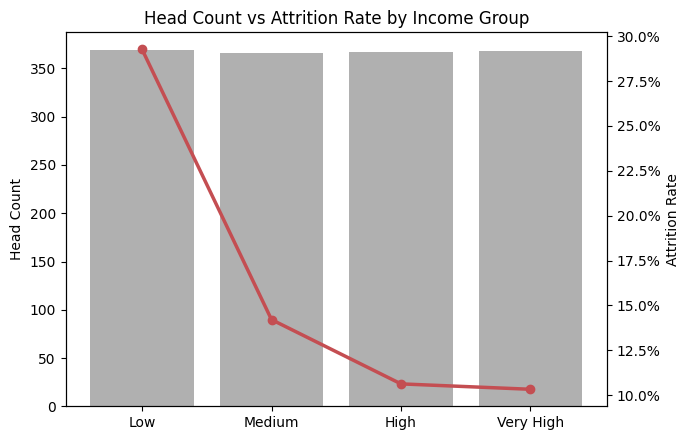

In [26]:
summary = df_clean.groupby("IncomeGroup", observed=True).agg(
    AttritionRate=("AttritionFlag", "mean"),
    HeadCount=("AttritionFlag", "size")
)

fig, ax1 = plt.subplots(figsize=(7,4.5))
ax1.bar(summary.index,
        summary["HeadCount"],
        color="#B0B0B0" ,
        label="Head Count")
ax1.set_ylabel("Head Count")

ax2= ax1.twinx()
ax2.plot(summary.index,
         summary["AttritionRate"],
         color= "#C44E52",
         marker="o",
         linewidth=2.5,
         label="Attrition Rate")
ax2.set_ylabel("Attrition Rate")
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

plt.title("Head Count vs Attrition Rate by Income Group")
fig.tight_layout()
plt.savefig("1_income_combo.png", dpi=150)
plt.show()

Attrition rate declines steadily from Low to Very High income, while group sizes remain nearly equal — ruling out a small-sample artifact.

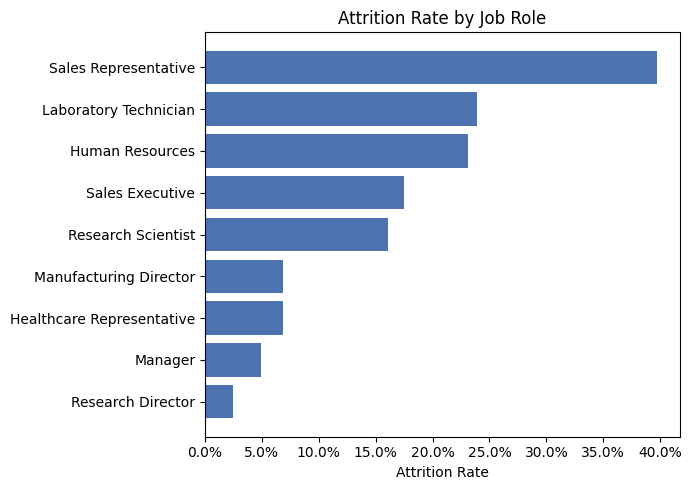

In [27]:
role_rate= df_clean.groupby("JobRole")["AttritionFlag"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7,5))

ax.barh(role_rate.index, role_rate.values, color="#4C72B0")
ax.set_xlabel("Attrition Rate")
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.title("Attrition Rate by Job Role")
plt.tight_layout()
plt.savefig("2_role_horizontal.png", dpi=150)
plt.show()

Sales Representative stands out as the single highest-risk role, far above every other position in the company

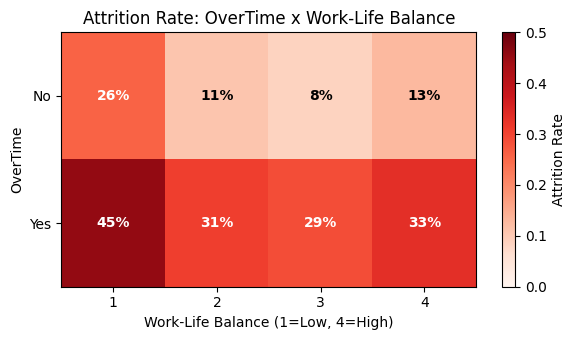

In [28]:
pivot = df_clean.groupby(["OverTime", "WorkLifeBalance"])["AttritionFlag"].mean().unstack()

fig, ax = plt.subplots(figsize=(6, 3.5))

im= ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=0.5, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Work-Life Balance (1=Low, 4=High)")
ax.set_ylabel("OverTime")

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i,j]
        ax.text(j,i, f"{val*100:.0f}%",
                ha="center",
                va="center",
                color="white" if val>0.25 else "black", fontweight="bold")

plt.colorbar(im, label="Attrition Rate")
plt.title("Attrition Rate: OverTime x Work-Life Balance")
plt.tight_layout()

plt.savefig("3_overtime_wlb_heatmap.png", dpi=150)
plt.show()

The darkest cell (OverTime=Yes, WLB=1) marks the highest-risk segment, but overtime elevates attrition across every work-life balance level.

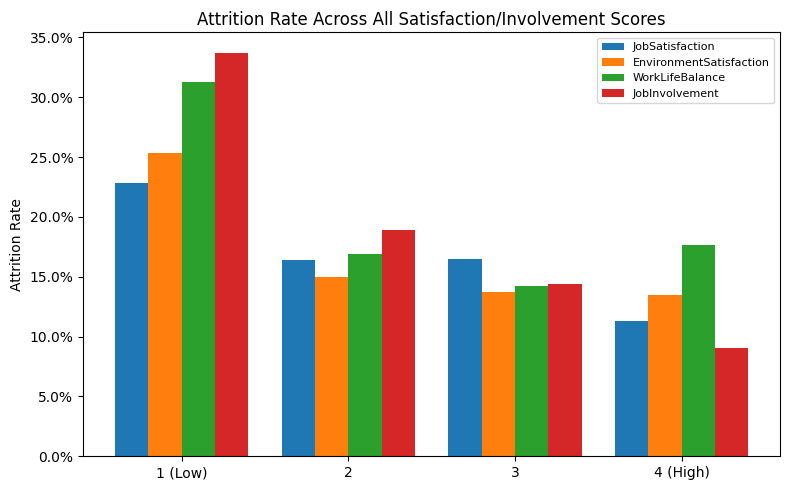

In [29]:
factors = ["JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance", "JobInvolvement"]
combined= pd.DataFrame({
    f: df_clean.groupby(f)["AttritionFlag"].mean() for f in factors
})

x = np.arange(1,5)
width = 0.2

fig, ax = plt.subplots(figsize=(8,5))
for i,f in enumerate(factors):
    ax.bar(x + i*width, combined[f].values, width=width, label=f)

ax.set_xticks(x+width*1.5)
ax.set_xticklabels(["1 (Low)", "2", "3", "4 (High)"])
ax.set_ylabel("Attrition Rate")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(fontsize=8)
plt.title("Attrition Rate Across All Satisfaction/Involvement Scores")
plt.tight_layout()

plt.savefig("4_satisfaction_grouped.png", dpi=150)
plt.show()

Job Involvement shows the steepest, most consistent decline across score levels, making it the strongest driver among the four satisfaction-type factors.

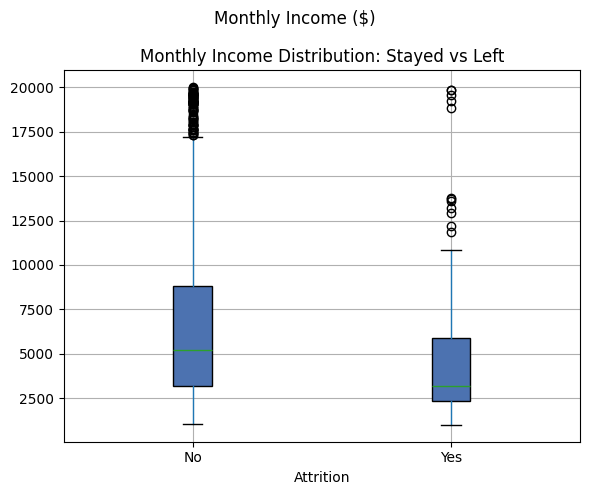

In [30]:
fig, ax = plt.subplots(figsize=(6,5))
df_clean.boxplot(column="MonthlyIncome",by="Attrition", ax=ax,
                patch_artist= True,
                boxprops= dict(facecolor="#4C72B0"))

plt.title("Monthly Income Distribution: Stayed vs Left")
plt.suptitle("Monthly Income ($)")
plt.tight_layout()

plt.savefig("5_income_boxplot.png", dpi=150)
plt.show()

The income gap between Stayed and Left isn't driven by a few outliers — the entire distribution for employees who left sits lower